In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
os.getcwd()

'C:\\Users\\User\\Documents\\Customer-Churn-Prediction\\notebook'

In [3]:
import os
os.listdir("../data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [9]:
df["TotalCharges"].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [10]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
df = df[df["TotalCharges"] != " "] #removing the blank spaces by dlting 11 cols

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

# feature selection

In [14]:
df.drop('customerID',axis=1,inplace=True) #Modify the existing DataFrame itself

# Exploratory Data Analysis (EDA)

In [15]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [16]:
df['Churn'].value_counts(normalize=True)*100 # normalize gives percentage

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [17]:
pd.crosstab(df["Contract"],["Churn"]) #crosstab()-creates a frequency table showing how two categorical variables are related.
#It helps us understand relationships, such as how contract type is associated with customer churn."
#This is not churn analysis.

#This only tells us:

#How many customers have each type of contract. code is same as "df["Contract"].value_counts()"

col_0,Churn
Contract,
Month-to-month,3875
One year,1472
Two year,1685


In [18]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [19]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
#index-"For each row (each contract type), convert the counts into percentages."

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


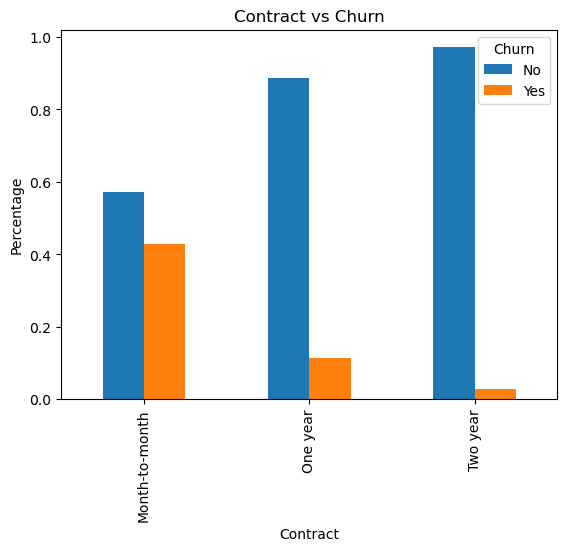

In [20]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index").plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Contract vs Churn")
plt.show()

In [21]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

#### Customers with higher monthly charges have a higher churn rate. The company should identify these customers and offer loyalty discounts, personalized plans, or additional benefits to improve retention.

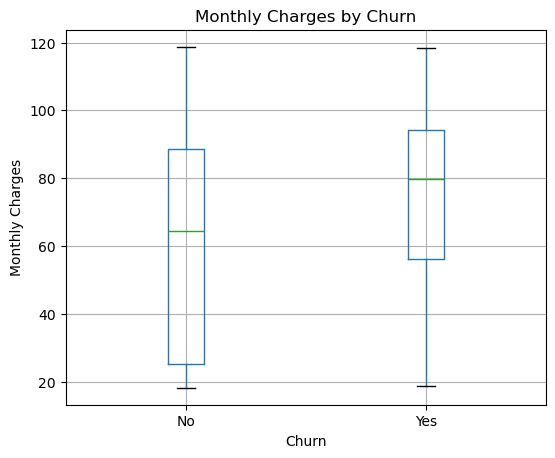

In [22]:
import matplotlib.pyplot as plt

df.boxplot(column="MonthlyCharges", by="Churn", figsize=(6,5))
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Business Insight:

Customers paying higher monthly charges are more likely to churn.

## Compare Average Tenure

In [23]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

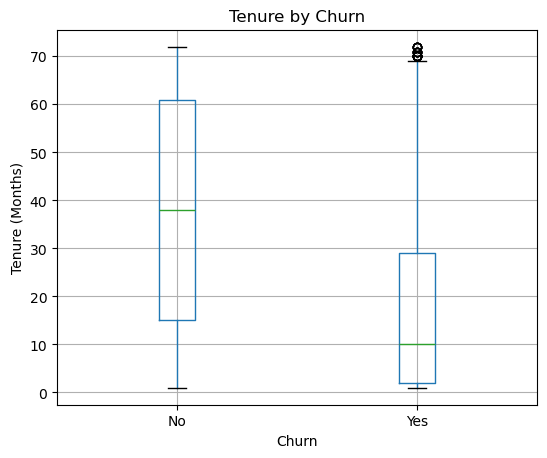

In [24]:
df.boxplot(column="tenure", by="Churn", figsize=(6,5))
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### business insiught
Half of the customers who churned stayed 10 months or less.

Half of the customers who stayed remained for about 38 months or more.

# InternetService vs Churn

In [25]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


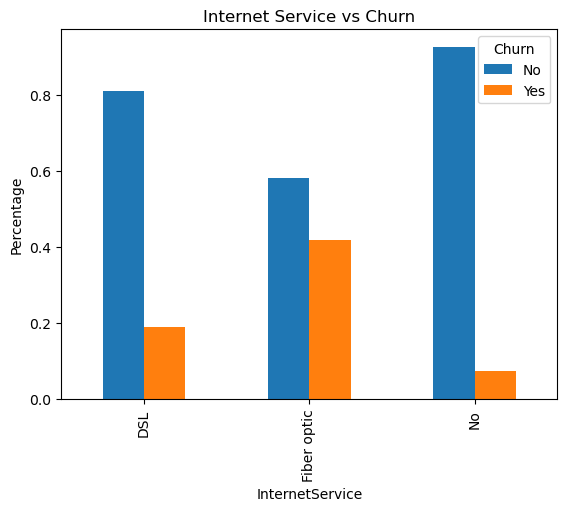

In [26]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index").plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Internet Service vs Churn")
plt.show()

# OnlineSecurity vs Churn

In [27]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index") * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


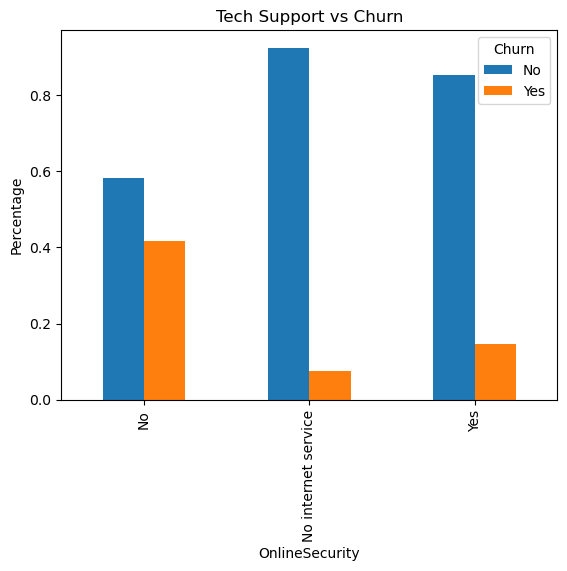

In [28]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index").plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Tech Support vs Churn")
plt.show()

# TechSupport vs Churn

In [29]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


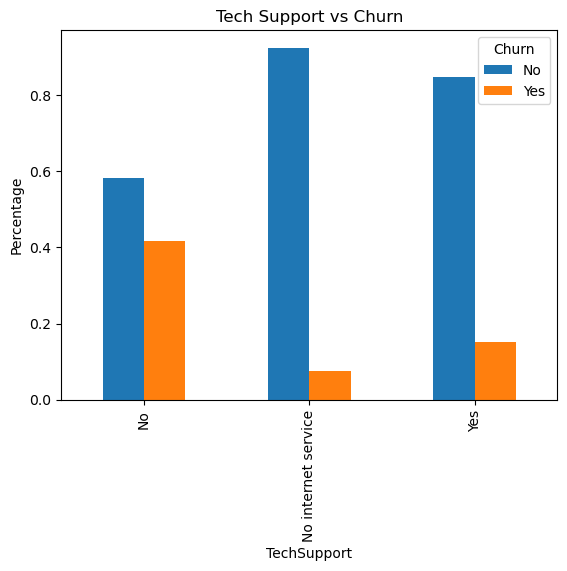

In [30]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index").plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Tech Support vs Churn")
plt.show()

# PaymentMethod vs Churn


In [31]:
pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index")*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


# TotalCharges vs Churn

In [32]:
pd.crosstab(df["TotalCharges"],df["Churn"],normalize="index")*100

Churn,No,Yes
TotalCharges,,
18.80,100.0,0.0
18.85,50.0,50.0
18.90,100.0,0.0
19.00,100.0,0.0
19.05,100.0,0.0
...,...,...
8564.75,100.0,0.0
8594.40,100.0,0.0
8670.10,100.0,0.0


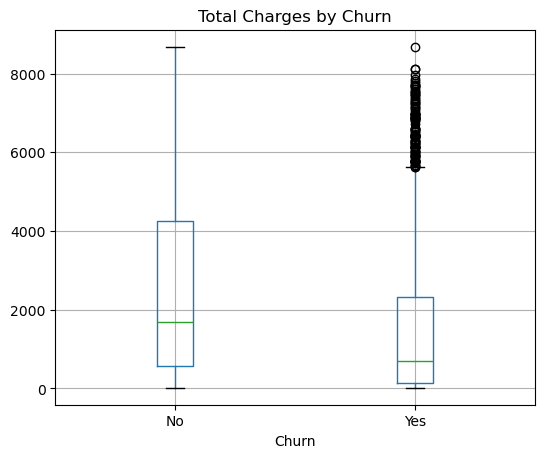

In [33]:
df.boxplot(column="TotalCharges", by="Churn", figsize=(6,5))
plt.title("Total Charges by Churn")
plt.suptitle("")
plt.show()

# Correlation Heatmap

In [34]:
df["Churn"]=df["Churn"].map({"No":0,"Yes":1}) #convert the target into numbers.

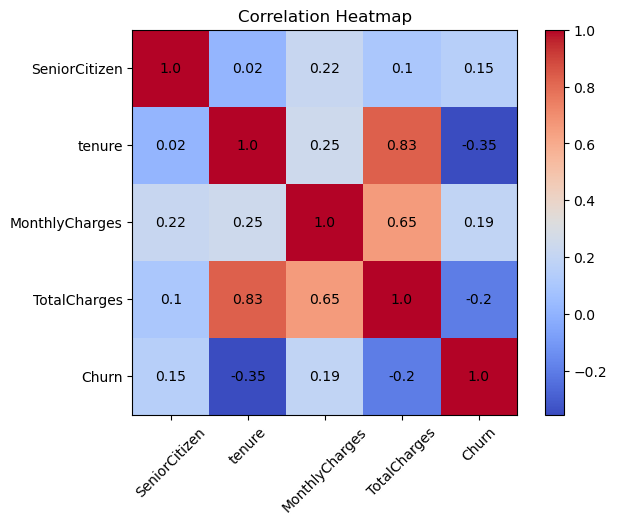

In [35]:
import matplotlib.pyplot as plt

corr = df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges","Churn"]].corr()

plt.figure(figsize=(7,5))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i,j],2),
                 ha='center', va='center', color='black')

plt.show()

In [36]:
print(df["Churn"].unique())

[0 1]


# 📌 Key Findings from EDA

### 1. Contract Type
- Customers with **Month-to-Month contracts** have the highest churn rate.
- Customers with **Two-Year contracts** have the lowest churn rate.

### 2. Customer Tenure
- Customers with **lower tenure** are significantly more likely to churn.
- Long-term customers are generally more loyal.

### 3. Monthly Charges
- Customers with **higher monthly charges** tend to churn more frequently.

### 4. Online Security
- Customers **without Online Security** show a much higher churn rate.

### 5. Tech Support
- Customers **without Tech Support** are more likely to leave the company.

### 6. Internet Service
- **Fiber Optic** customers exhibit the highest churn rate among all internet service types.

### 7. Payment Method
- Customers using **Electronic Check** have the highest churn rate compared to other payment methods.

## Business Recommendations

- Encourage customers to switch from **Month-to-Month** to long-term contracts.
- Improve onboarding and engagement for **new customers**.
- Offer discounts or personalized plans for customers with **high monthly charges**.
- Promote **Online Security** and **Tech Support** services.
- Investigate customer dissatisfaction among **Fiber Optic** users.
- Review the payment experience for customers using **Electronic Check**.

## Data preprocessing

In [37]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [38]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [39]:
binary_cols=[
    "gender",
    "Partner",
    "Dependents",
    "PaperlessBilling",
    "PhoneService",
    "Churn"
]
for col in binary_cols:
    print(col,":",df[col].unique())

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PaperlessBilling : ['Yes' 'No']
PhoneService : ['No' 'Yes']
Churn : [0 1]


## Label Encoding : 2 categories

In [40]:
df["gender"]=df["gender"].map({"Female":0,"Male":1})
df["Partner"] = df["Partner"].map({"No":0, "Yes":1})
df["Dependents"]=df["Dependents"].map({"No":0,"Yes":1})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"No":0, "Yes":1})
df["PhoneService"] = df["PhoneService"].map({"No":0, "Yes":1})


##### .map()

<pre> Means:Replace each value according to the dictionary.

In [41]:
df[binary_cols].head()

,gender,Partner,Dependents,PaperlessBilling,PhoneService,Churn
0,0,1,0,1,0,0
1,1,0,0,0,1,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


## One-Hot Encoding : 3 or more 

In [42]:
one_hot_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]


In [43]:
df=pd.get_dummies(         #Convert categorical columns into dummy (0/1) columns.
    df,
    columns=one_hot_cols,     #Apply One-Hot Encoding only to these columns.
    drop_first=True,             #This avoids something called Dummy Variable Trap
    dtype=int           #Without this, Pandas may create True/False.
)

In [44]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [46]:
print(df["Churn"].unique())

[0 1]


In [47]:
print(df["Churn"].value_counts(dropna=False))

Churn
0    5163
1    1869
Name: count, dtype: int64


## Separate Features (X) and Target (y)

In [48]:
X=df.drop("Churn",axis=1)
Y=df["Churn"]

In [49]:
print(X.shape)
print(Y.shape)

(7032, 30)
(7032,)


## Train-Test Split

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [52]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7860696517412935


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[913 120]
 [181 193]]


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Business insight
Our Logistic Regression model achieves 79% overall accuracy. 
It is very good at identifying customers who will stay (88% recall for non-churn), but it detects only 52% of customers who are actually going to churn. Since preventing churn is the business goal, we should improve the model to identify more at-risk customers.

# Feature Scaling

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])           #The scaler learns:Mean,Standard deviation

X_test[num_cols] = scaler.transform(X_test[num_cols])                   #The test data is never used for learning.

In [58]:
from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
y_pred_scaled = model_scaled.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))
print()

print(classification_report(y_test, y_pred_scaled))

Accuracy: 0.7867803837953091

Confusion Matrix:
[[915 118]
 [182 192]]

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Logistic Regression Performance After Feature Scaling

Feature scaling was applied using StandardScaler on the numerical features:
- tenure
- MonthlyCharges
- TotalCharges

After retraining Logistic Regression, the model achieved an accuracy of **78.68%**, which is very similar to the unscaled model.

The recall for churn customers remained almost unchanged, indicating that feature scaling did not significantly improve the model's ability to identify customers likely to churn.

Scaling removed the convergence warning and ensured the numerical features were on comparable scales, which is considered a good preprocessing practice for Logistic Regression.

# Next Model: Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier
dt_model= DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [62]:
dt_pred = dt_model.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, dt_pred))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print()

print(classification_report(y_test, dt_pred))

Accuracy: 0.7263681592039801

Confusion Matrix:
[[830 203]
 [182 192]]

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



In [64]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [65]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
rf_pred = rf_model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, rf_pred))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print()

print(classification_report(y_test, rf_pred))

Accuracy: 0.7867803837953091

Confusion Matrix:
[[934  99]
 [201 173]]

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [68]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.193968
7,MonthlyCharges,0.167620
4,tenure,0.165879
11,InternetService_Fiber optic,0.039835
28,PaymentMethod_Electronic check,0.037079
0,gender,0.029085
26,Contract_Two year,0.029049
6,PaperlessBilling,0.026621
14,OnlineSecurity_Yes,0.026389
25,Contract_One year,0.025441


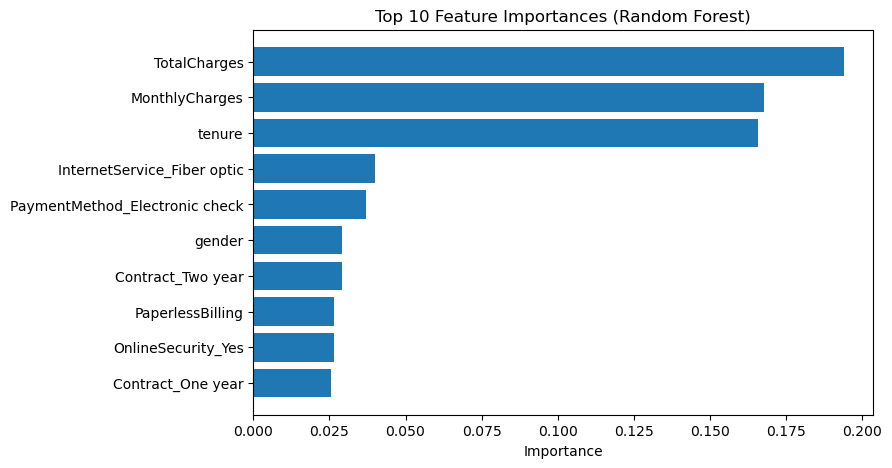

In [69]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

## Random Forest Feature Importance

1. **TotalCharges** is the most influential feature for predicting customer churn.

2. **MonthlyCharges** and **tenure** are also major factors, indicating that pricing and customer loyalty strongly affect churn.

3. Customers using **Fiber Optic** internet have a higher influence on churn prediction.

4. Customers paying through **Electronic Check** are more likely to churn.

5. **Long-term contracts (One Year and Two Year)** reduce the likelihood of customer churn.

6. **Online Security** has a positive impact on customer retention.

7. **Gender** has very little influence on customer churn.

In [70]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

In [71]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [72]:
xgb_pred = xgb_model.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print()

print(classification_report(y_test, xgb_pred))

Accuracy: 0.7938877043354655

Confusion Matrix:
[[933 100]
 [190 184]]

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Model Comparison

Five machine learning models were trained and evaluated:

| Model | Accuracy |
|--------|-----------|
| Logistic Regression | 78.68% |
| Decision Tree | 72.64% |
| Decision Tree (max_depth=5) | 77.54% |
| Random Forest | 78.68% |
| XGBoost | **79.39%** |

XGBoost achieved the highest overall accuracy and precision, making it the best-performing model for this project.

The tuned Decision Tree achieved the highest recall (0.59), indicating it was better at identifying customers who were likely to churn.

Considering overall performance, XGBoost was selected as the final model.

In [74]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [75]:
import shap
explainer=shap.TreeExplainer(xgb_model)

In [77]:
shap_values=explainer.shap_values(X_test) #This computes the contribution of every feature for every prediction

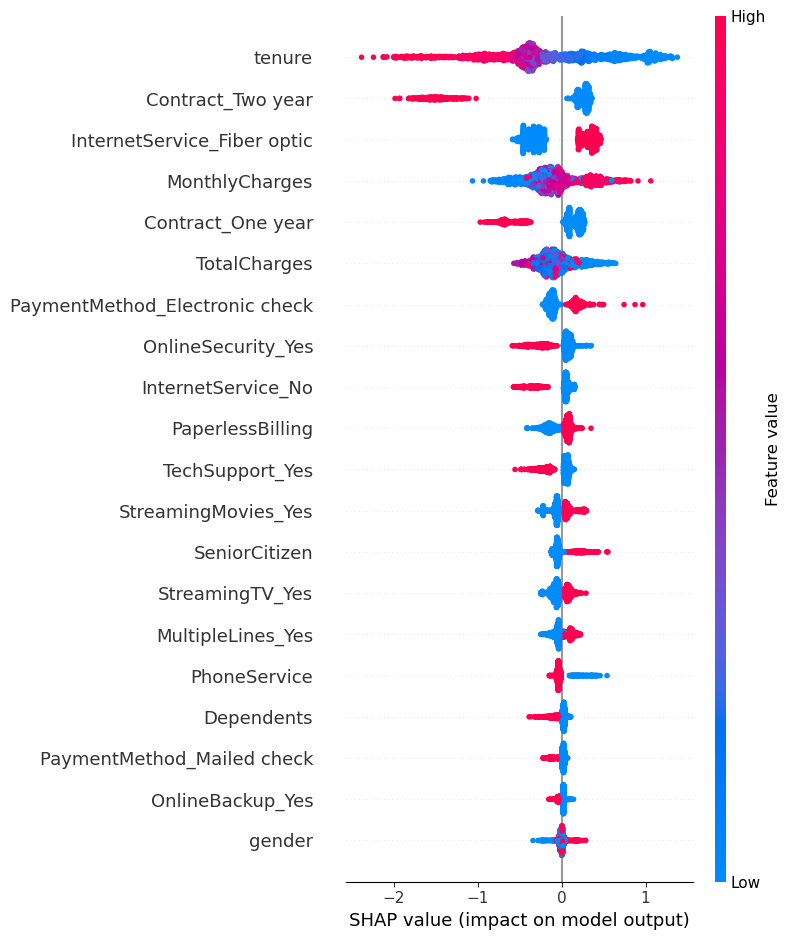

In [78]:
shap.summary_plot(shap_values, X_test)

#### Left side (negative) → pushes prediction toward No Churn
#### Right side (positive) → pushes prediction toward Churn

## SHAP Explainability

SHAP (SHapley Additive exPlanations) was used to interpret the XGBoost model.

### Key Observations

1. **Tenure** is the most influential feature.
   - Customers with lower tenure are more likely to churn.
   - Customers with higher tenure are more likely to stay.

2. Customers with **Two-Year** and **One-Year** contracts have a lower probability of churn.

3. Customers using **Fiber Optic** internet are more likely to churn.

4. Higher **Monthly Charges** increase the likelihood of churn.

5. **Total Charges** also contribute significantly to the model's predictions.

Overall, SHAP provides transparent explanations by showing how each feature influences the model's prediction for customer churn.

In [80]:
import joblib
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [81]:
model = joblib.load("xgb_model.pkl")

In [82]:
prediction = model.predict(X_test[:5])
print(prediction)

[0 0 1 0 0]
